In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

np.random.seed(42)
N = 2000

CLASSES = ['Material Weakness', 'Significant Deficiency', 'Control Deficiency',
           'Compliance Violation', 'Fraud Risk']

# Génération des variables contextuelles
company_size    = np.random.choice(['Small','Medium','Large'], N, p=[0.30,0.45,0.25])
industry_sector = np.random.choice(['Finance','Technology','Manufacturing','Healthcare','Energy','Retail'], N)
control_area    = np.random.choice(['IT Controls','Financial Reporting','HR & Payroll','Operations','Compliance'], N)
deficiency_type = np.random.choice(CLASSES, N, p=[0.15,0.25,0.35,0.18,0.07])

# Génération des variables numériques corrélées à la classe
params = {
    'risk_score':   [(82,10),(65,12),(42,12),(58,14),(88,8)],
    'num_findings': [(12,3),(7,2),(4,2),(6,2),(15,4)],
    'remediation':  [(180,40),(90,25),(45,15),(70,20),(240,50)],
}
prior_prob = [0.75,0.55,0.35,0.50,0.85]

risk_col, find_col, rem_col, prior_col = [], [], [], []
for lbl in deficiency_type:
    i = CLASSES.index(lbl)
    risk_col.append(np.clip(np.random.normal(*params['risk_score'][i]), 10, 100))
    find_col.append(int(np.clip(np.random.normal(*params['num_findings'][i]), 1, 30)))
    rem_col.append(int(np.clip(np.random.normal(*params['remediation'][i]), 7, 365)))
    prior_col.append(int(np.random.rand() < prior_prob[i]))

df = pd.DataFrame({
    'company_size': company_size,
    'industry_sector': industry_sector,
    'control_area': control_area,
    'num_findings': find_col,
    'remediation_days': rem_col,
    'risk_score': np.round(risk_col, 2),
    'prior_deficiency': prior_col,
    'deficiency_type': deficiency_type,
})

print("Dataset chargé !")
print(df.shape)
df.head()

Dataset chargé !
(2000, 8)


,company_size,industry_sector,control_area,num_findings,remediation_days,risk_score,prior_deficiency,deficiency_type
0,Medium,Healthcare,HR & Payroll,6,54,39.39,0,Control Deficiency
1,Large,Manufacturing,HR & Payroll,2,41,45.48,1,Control Deficiency
2,Medium,Healthcare,HR & Payroll,15,161,100.00,1,Material Weakness
3,Medium,Retail,Financial Reporting,3,58,74.38,1,Significant Deficiency
4,Small,Technology,IT Controls,18,144,83.04,1,Material Weakness


In [2]:
# Encodage One-Hot des catégorielles
X = pd.get_dummies(df.drop(columns=['deficiency_type']),
                   columns=['company_size','industry_sector','control_area'],
                   drop_first=True)

# Encodage de la cible
le = LabelEncoder()
y = le.fit_transform(df['deficiency_type'])
print("Classes :", list(le.classes_))

# Standardisation des colonnes numériques continues
scaler = StandardScaler()
X[['num_findings','remediation_days','risk_score']] = scaler.fit_transform(
    X[['num_findings','remediation_days','risk_score']])

print(X.shape)
X.head()

Classes : ['Compliance Violation', 'Control Deficiency', 'Fraud Risk', 'Material Weakness', 'Significant Deficiency']
(2000, 15)


,num_findings,remediation_days,risk_score,prior_deficiency,company_size_Medium,company_size_Small,industry_sector_Finance,industry_sector_Healthcare,industry_sector_Manufacturing,industry_sector_Retail,industry_sector_Technology,control_area_Financial Reporting,control_area_HR & Payroll,control_area_IT Controls,control_area_Operations
0,-0.141986,-0.615651,-1.014115,0,True,False,False,True,False,False,False,False,True,False,False
1,-1.104601,-0.816986,-0.706955,1,False,False,False,False,True,False,False,False,True,False,False
2,2.023899,1.041490,2.042854,1,True,False,False,True,False,False,False,False,True,False,False
3,-0.863947,-0.553702,0.750665,1,True,False,False,False,False,True,False,True,False,False,False
4,2.745860,0.778206,1.187447,1,False,True,False,False,False,False,True,False,False,True,False


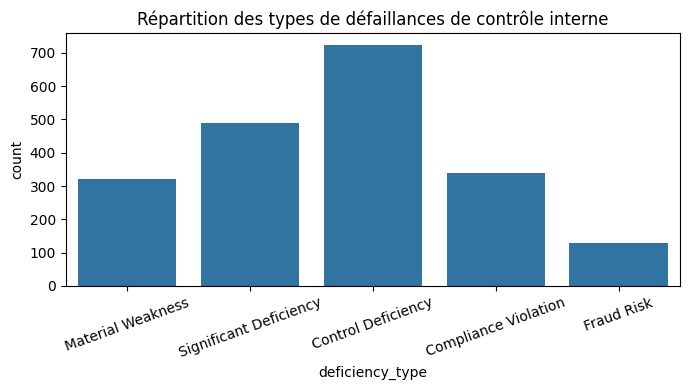

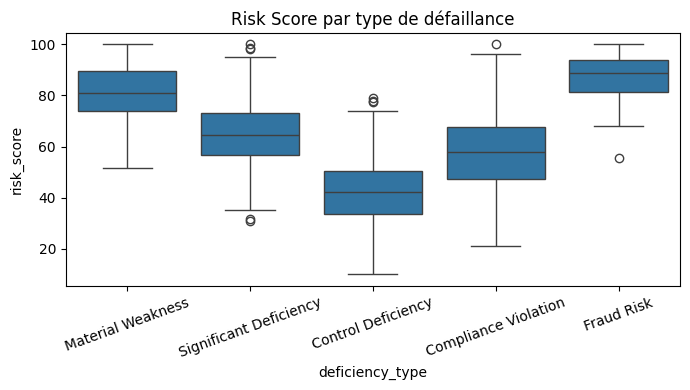

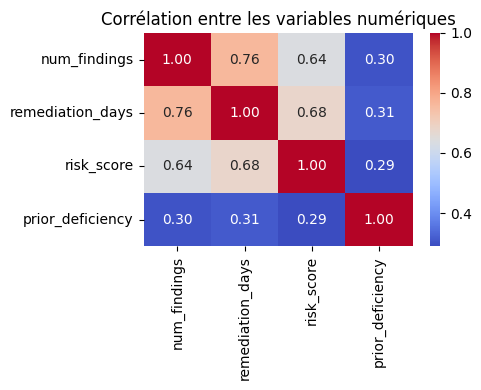

In [3]:
# Distribution des classes
plt.figure(figsize=(7,4))
sns.countplot(x=df['deficiency_type'], order=CLASSES)
plt.xticks(rotation=20)
plt.title("Répartition des types de défaillances de contrôle interne")
plt.tight_layout()
plt.show()

# Risk score par type de défaillance
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='deficiency_type', y='risk_score', order=CLASSES)
plt.xticks(rotation=20)
plt.title("Risk Score par type de défaillance")
plt.tight_layout()
plt.show()

# Heatmap de corrélation
plt.figure(figsize=(5,4))
corr = df[['num_findings','remediation_days','risk_score','prior_deficiency']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Corrélation entre les variables numériques")
plt.tight_layout()
plt.show()

In [4]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# 3 modèles
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest":       RandomForestClassifier(random_state=42),
    "KNN":                 KNeighborsClassifier()
}

# Validation croisée (k-fold)
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print(f"{name} — Accuracy CV : {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression — Accuracy CV : 0.7638 ± 0.0102
Random Forest — Accuracy CV : 0.7512 ± 0.0165
KNN — Accuracy CV : 0.6937 ± 0.0214


In [5]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                       param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_rf.best_params_)
print("Meilleure accuracy CV :", round(grid_rf.best_score_, 4))

Meilleurs paramètres : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Meilleure accuracy CV : 0.7663


Rapport de classification :
                        precision    recall  f1-score   support

  Compliance Violation       0.42      0.22      0.29        68
    Control Deficiency       0.85      0.92      0.88       145
            Fraud Risk       0.82      0.56      0.67        25
     Material Weakness       0.83      0.89      0.86        64
Significant Deficiency       0.63      0.78      0.70        98

              accuracy                           0.74       400
             macro avg       0.71      0.67      0.68       400
          weighted avg       0.72      0.74      0.72       400



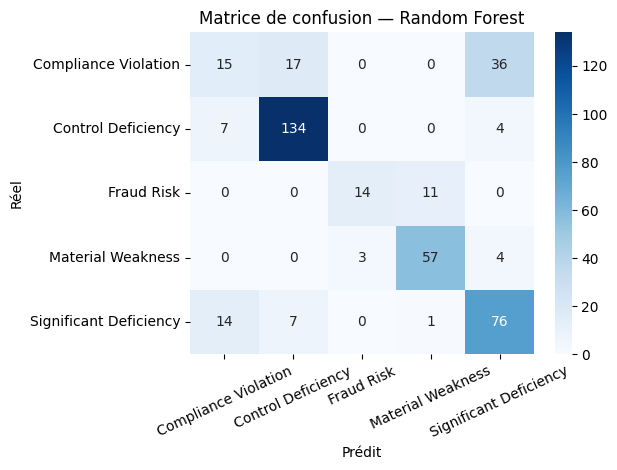

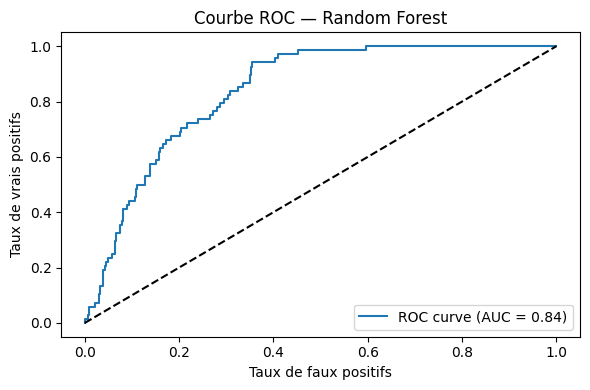

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

best_model = grid_rf.best_estimator_
y_pred = best_model.predict(X_test)

print("Rapport de classification :")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Prédit"); plt.ylabel("Réel")
plt.title("Matrice de confusion — Random Forest")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# Courbe ROC (classe Material Weakness vs reste)
y_proba = best_model.predict_proba(X_test)[:, 0]
y_bin   = (y_test == 0).astype(int)
fpr, tpr, _ = roc_curve(y_bin, y_proba)
auc_score   = roc_auc_score(y_bin, y_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_score:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("Taux de faux positifs"); plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC — Random Forest")
plt.legend()
plt.tight_layout()
plt.show()